In [1]:
# Add import 
import sys
import torch 
from torch import nn
from torch import optim
import tqdm
import numpy as np
import matplotlib.pyplot as plt
# allow reload of python modules
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
from dataset.RobotPathDataset.normalizer import MinMaxFeatureNormalizer

from model.models import EMA
import copy


# Hyperparams Constants

In [2]:
normalizer = MinMaxFeatureNormalizer()
encoder_normalizer = MinMaxFeatureNormalizer()
CONFIG = {
    # Model configuration
    'representation_dim': 64,
    # Hyperparameters for training
    'batch_size': 32,
    'num_epochs': 100,
    'learning_rate': 0.001,
    'optimizer': optim.Adam,
    # Hyperparameters for diffusion process
    'noise_steps': 100,
    'normalize': True,
    'normalizer':normalizer,
    'encoder_normalizer':encoder_normalizer,
    'scheduler': optim.lr_scheduler.ExponentialLR,
    'ema': EMA(0.99),
    'scheduler_gamma': 0.999,

    # Dataset specific configuration
    'n_paths_per_world': 50,
    'n_worlds': 500,
    'n_waypoints': 100,
}

# Dataloader

In [3]:
from dataset import RobotPathDataset

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
device

cuda:0


device(type='cuda', index=0)

### Normalizer

In [5]:
file = 'D:\Desktop\ADLR\RobotPathData\data\SingleSphere02_all.db'
dataset = RobotPathDataset(file, n_paths_per_world=CONFIG['n_paths_per_world'], n_worlds=CONFIG['n_worlds'],  n_waypoints=CONFIG['n_waypoints'],   normalizer=CONFIG['normalizer'])
print(f' sample shape {dataset[0]["path"].shape} with {len(dataset)} samples')
indx_sample = 5
sample = dataset[indx_sample]

world_indx: 0, world_distance_field_images: torch.Size([64, 64])
world_indx: 1, world_distance_field_images: torch.Size([64, 64])
world_indx: 2, world_distance_field_images: torch.Size([64, 64])
world_indx: 3, world_distance_field_images: torch.Size([64, 64])
world_indx: 4, world_distance_field_images: torch.Size([64, 64])
world_indx: 5, world_distance_field_images: torch.Size([64, 64])
world_indx: 6, world_distance_field_images: torch.Size([64, 64])
world_indx: 7, world_distance_field_images: torch.Size([64, 64])
world_indx: 8, world_distance_field_images: torch.Size([64, 64])
world_indx: 9, world_distance_field_images: torch.Size([64, 64])
world_indx: 10, world_distance_field_images: torch.Size([64, 64])
world_indx: 11, world_distance_field_images: torch.Size([64, 64])
world_indx: 12, world_distance_field_images: torch.Size([64, 64])
world_indx: 13, world_distance_field_images: torch.Size([64, 64])
world_indx: 15, world_distance_field_images: torch.Size([64, 64])
world_indx: 16, worl

d:\Desktop\ADLR\RobotPathData\dataset\RobotPathDataset\torch_dataset.py:57: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.data = torch.tensor(path_coordinates, device=device) # torch tensor


data shape: torch.Size([25000, 100, 2]), min_values: tensor([0, 0], device='cuda:0'), max_values: tensor([10, 10], device='cuda:0'), n_worlds:244, samples: 25000
 sample shape torch.Size([100, 2]) with 25000 samples


In [6]:

np.unique(dataset.worlds_indx)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  15,  16,  17,  18,  20,  21,  22,  23,  24,  25,  27,  30,
        32,  34,  35,  36,  38,  40,  41,  43,  44,  45,  46,  48,  49,
        50,  51,  52,  53,  54,  56,  57,  58,  59,  60,  62,  63,  64,
        65,  67,  68,  69,  70,  72,  74,  75,  77,  79,  82,  84,  85,
        86,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99,
       100, 102, 103, 104, 105, 106, 110, 111, 112, 113, 114, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 130, 132,
       133, 135, 136, 138, 139, 140, 142, 145, 146, 147, 148, 150, 154,
       155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 168,
       169, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182,
       183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195,
       196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208,
       209, 210, 211, 212, 214, 215, 216, 217, 219, 220, 221, 22

In [7]:
denormalized_sample = normalizer.denormalize(sample['path'])
denormalized_sample

tensor([[8.4730, 0.6584],
        [8.4462, 0.7924],
        [8.4195, 0.9265],
        [8.3927, 1.0605],
        [8.3659, 1.1945],
        [8.3392, 1.3285],
        [8.3130, 1.4627],
        [8.2902, 1.5973],
        [8.2673, 1.7320],
        [8.2444, 1.8667],
        [8.2215, 2.0014],
        [8.1987, 2.1361],
        [8.1766, 2.2709],
        [8.1577, 2.4063],
        [8.1388, 2.5417],
        [8.1199, 2.6772],
        [8.1011, 2.8126],
        [8.0822, 2.9480],
        [8.0633, 3.0834],
        [8.0644, 3.2187],
        [8.0847, 3.3539],
        [8.1050, 3.4890],
        [8.1253, 3.6242],
        [8.1456, 3.7594],
        [8.1659, 3.8945],
        [8.1862, 4.0297],
        [8.2095, 4.1642],
        [8.2411, 4.2972],
        [8.2727, 4.4301],
        [8.3042, 4.5631],
        [8.3358, 4.6960],
        [8.3674, 4.8290],
        [8.3990, 4.9619],
        [8.4305, 5.0948],
        [8.4621, 5.2278],
        [8.4937, 5.3607],
        [8.5253, 5.4937],
        [8.5568, 5.6266],
        [8.5

In [8]:
WORLD_IMG = sample['world_img'] 

In [9]:
from torch.utils.data import DataLoader
batch_size = CONFIG['batch_size']
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True)
# iterate over the dataset
# get the first batch
sample_batch = next(iter(dataloader))


In [10]:
sample_batch['world_indx'].shape

torch.Size([32])

# Archtechture

### encoder

In [11]:
from model import WorldIndexEmbeder, FlattenEmbeder

In [12]:
embedding_dim = CONFIG['representation_dim']
# Define the model
sample_input = sample['world_distance_field_img']
encoder = FlattenEmbeder(input_sample=sample_input, embedding_dim=embedding_dim, normalizer=None)
encoder

FlattenEmbeder(
  (embedding): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=64, bias=True)
    (2): SELU()
  )
)

### Model and diffusion

In [13]:
from model import Diffusion, TemporalUnet

In [14]:
# Create the UNet
transition_dim = sample['path'].shape[-1] # transition_dim is the dimension the model should predict. not the timesteps
model = TemporalUnet(horizon=CONFIG['n_waypoints'], transition_dim=transition_dim, dim=CONFIG['representation_dim'], encoder=encoder, device=device)

[ models/temporal ] Channel dimensions: [(2, 64), (64, 128), (128, 256)]
[(2, 64), (64, 128), (128, 256)]


In [15]:
model.to(device);
model.device

device(type='cuda', index=0)

In [16]:
# create the diffusion model
diffusion = Diffusion(input_shape=sample['path'].shape, noise_steps=CONFIG['noise_steps'], device=device)

In [17]:
# test the model
x = sample_batch
timesteps = diffusion.sample_timesteps(batch_size)
y = model(x['path'], timesteps)
assert y.shape == (batch_size, CONFIG['n_waypoints'], 2)
y.shape

d:\Apps\anaconda\envs\torch-env\lib\site-packages\torch\nn\modules\conv.py:306: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ..\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return F.conv1d(input, weight, bias, self.stride,


torch.Size([32, 100, 2])

In [18]:
# noise input 
timesteps = diffusion.sample_timesteps(batch_size)
x_t, noise = diffusion.noise_input(sample_batch['path'],timesteps)
x_t.shape, noise.shape

(torch.Size([32, 100, 2]), torch.Size([32, 100, 2]))

In [19]:
import matplotlib.cm as cm

number_of_samples_to_show = 5
# test the model
x = sample_batch['path'][0:number_of_samples_to_show]
timesteps = diffusion.sample_timesteps(number_of_samples_to_show)
y = model(x, timesteps)
# noise input 
timesteps = diffusion.sample_timesteps(number_of_samples_to_show)
x_t, noise = diffusion.noise_input(x,timesteps)
x_t.shape, noise.shape
# plot sample entire batch
colors = cm.rainbow(np.linspace(0, 1, len(x)))
def visualize_diffusion_process(x, x_t, normalizer=None):
    if normalizer:
        x = normalizer.denormalize(x)
        x_t = normalizer.denormalize(x_t)
    x = x.cpu().detach().numpy()
    x_t = x_t.cpu().detach().numpy()
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    for i in range(number_of_samples_to_show):
        ax.plot(x[i, :, 0], x[i, :, 1], 'o-', label='input', color=colors[i])
        ax.plot(x_t[i, :, 0], x_t[i, :, 1], 'o-', label=f'noise t={timesteps[i]}', color=colors[i], alpha=0.5)
    plt.legend()
    plt.show()

print(timesteps)
# visualize_diffusion_process(x, x_t, normalizer=normalizer)
# visualize_diffusion_process(x, x_t, normalizer=None)


tensor([58, 57, 55, 44, 39], device='cuda:0')


# Training

In [20]:
# write training loop 
import torch.optim as optim
import torch.nn as nn


In [21]:
from LoggingManager import LoggingManager
logging_manager = LoggingManager(experiement_name='path-dataset-multiworld=10-distancefield-embedder')
logging_manager.log_config(CONFIG);

Logging to logs\path-dataset-multiworld=10-distancefield-embedder/11h-05m-19-05-2024/logs.log


### Set up validation and plotting function

In [22]:
def plot_diffusions(intermediates, world_imgs=None, normalizer=None, max_plots=8):
    # choose 5 intermediates equally spaced with the last one being at the end indexand 
    intermediates_indx_to_draw = [0, len(intermediates) //4 ,len(intermediates)//2, (3* len(intermediates) ) // 4,len(intermediates)-1]
    if normalizer:
        intermediates = normalizer.denormalize(intermediates, is_numpy=True)
    intermediates = intermediates[intermediates_indx_to_draw]
    intermediates = intermediates.transpose(1,0,2,3)
    if intermediates.shape[0] > max_plots:
        intermediates = intermediates[:max_plots]
    number_of_samples = intermediates.shape[0]
    number_of_steps = intermediates.shape[1]
    fig , ax = plt.subplots(number_of_samples,number_of_steps, figsize=(20,20))
    for i, sample in enumerate(intermediates):
        for j, step in enumerate(sample): 
            ax[i, j].plot(step[:, 0], step[:, 1], 'o-', label='l', color='red', alpha=0.8)
            if world_imgs is not None:
                ax[i, j].imshow(world_imgs[i].T, extent=[0, 10, 0, 10], origin='lower', cmap='binary')
             # put 1st point in green and last point in red
            ax[i, j].plot(step[0, 0], step[0, 1], 'o-', label='start', color='green')
            ax[i, j].plot(step[-1, 0], step[-1, 1], 'o-', label='end', color='yellow')
    plt.tight_layout()
    return fig

# plot = plot_diffusions(intermediates, world_img=WORLD_IMG)
# logging_manager.tb_log_figure(plot, 'diffusion_samples')

In [23]:
def plot_noise_and_predicted_noise(sample, noise, predicted_noise, timesteps, normalizer=None, max_plots=8):

    # if any of the inputs are in the GPU move them to CPU
    if sample.is_cuda:
        sample = sample.clone().cpu().detach().numpy()
    if noise.is_cuda:
        noise = noise.clone().cpu().detach().numpy()
    if predicted_noise.is_cuda:
        predicted_noise = predicted_noise.clone().cpu().detach().numpy()
    if timesteps.is_cuda:
        timesteps = timesteps.clone().cpu().detach().numpy()

    # get per sample differnce betwen noise and predicted noise MSE
    mse_per_sample = np.mean(np.square(noise - predicted_noise), axis=(1, 2))
    sample_plus_noise = sample + noise
    sample_plus_predicted_noise = sample + predicted_noise
    # denormalize the samples
    if normalizer:
        sample = normalizer.denormalize(sample, is_numpy=True)
        sample_plus_noise = normalizer.denormalize(sample_plus_noise, is_numpy=True)
        sample_plus_predicted_noise = normalizer.denormalize(sample_plus_predicted_noise, is_numpy=True)
    if sample.shape[0] > max_plots:
        sample = sample[:max_plots]
        sample_plus_noise = sample_plus_noise[:max_plots]
        sample_plus_predicted_noise = sample_plus_predicted_noise[:max_plots]
        mse_per_sample = mse_per_sample[:max_plots]
        timesteps = timesteps[:max_plots]
    n_cols = 2
    n_rows = sample.shape[0] // n_cols 
    fig, ax = plt.subplots(n_rows , n_cols, figsize=(20, 20))
    for i in range(n_rows):
        for j in range(n_cols):
            ax[i, j].plot(sample[j*n_cols + i, :, 0], sample[j*n_cols + i, :, 1], 'o-', label='input', color='blue')
            ax[i, j].plot(sample_plus_noise[j*n_cols + i, :, 0], sample_plus_noise[j*n_cols + i, :, 1], 'o-', label=f'noised', color='green', alpha=0.5)
            ax[i, j].plot(sample_plus_predicted_noise[j*n_cols + i, :, 0], sample_plus_predicted_noise[j*n_cols + i, :, 1], 'o-', label=f'predicted', color='red', alpha=0.5)
            ax[i, j].set_title(f'MSE={mse_per_sample[j*n_cols + i]:.3f}, t={timesteps[j*n_cols + i]}')  # Title for each subplot

    plt.legend()
    return fig


# Train 

In [24]:
START_FROM_CHECKPOINT = False
Checkpoint_file = r"D:\Desktop\ADLR\RobotPathData\logs\path-dataset-multiworld=10-distancefield-embedder\15h-08m-18-05-2024\model-epoch_16-loss_0.043-time_15h-43m-18-05-2024"

In [25]:
# train the model

import random


optimizer = CONFIG['optimizer'](model.parameters(), lr=CONFIG['learning_rate'])
scheduler = CONFIG['scheduler'](optimizer, gamma=CONFIG['scheduler_gamma'])
ema = CONFIG['ema']
ema_model = copy.deepcopy(model).eval().requires_grad_(False)

# Restart from checkpoint 
if START_FROM_CHECKPOINT:
    model, optimizer, scheduler, epoch, loss = logging_manager.load_checkpoint(model, optimizer, scheduler, filename=Checkpoint_file)
    ema.step_ema(ema_model,model)
    logging_manager.log_message(f'Restarting from epoch {epoch} with loss {loss}')

for epoch in range(CONFIG['num_epochs']):
    pbar = tqdm.tqdm(dataloader, total=len(dataloader))
    running_loss = 0.0
    # iterate over the dataset
    for i, batch_and_info in enumerate(pbar):
        batch, batch_world_indx, batch_world_img, batch_world_distance_field_img = batch_and_info['path'], batch_and_info['world_indx'], batch_and_info['world_img'], batch_and_info['world_distance_field_img']
        
        # Training step
        model.train()
        optimizer.zero_grad()
        x = batch.to(device)
        cond = batch_world_distance_field_img.to(device)
        # preturb input. add noise to it
        timesteps_choosen = diffusion.sample_timesteps(x.shape[0])
        x_t, noise = diffusion.noise_input(x,timesteps_choosen)
        # get model to predict the noise
        pred_noise = model(x_t, timesteps_choosen, cond)
        
        # print the encoder weights to make sure it is training 

        loss = nn.MSELoss()(noise, pred_noise)
        loss.backward()
        optimizer.step()
        # update the EMA model
        ema.step_ema(ema_model,model)
        running_loss += loss.item()
        logging_manager.plot_losses(loss.item())
        pbar.set_postfix({'loss': loss.item()})
        if i % 1000 == 0:

            # plot noise and predicted noise
            plot = plot_noise_and_predicted_noise(x, noise, pred_noise, timesteps_choosen, normalizer=CONFIG['normalizer'])
            logging_manager.tb_log_figure(plot, 'noise_and_predicted_noise', step= i + epoch * len(dataloader))

            # plot noise and predicted noise ema
            ema_model.eval()
            pred_noise_ema = ema_model(x_t, timesteps_choosen)
            plot = plot_noise_and_predicted_noise(x, noise, pred_noise_ema, timesteps_choosen, normalizer=CONFIG['normalizer'])
            logging_manager.tb_log_figure(plot, 'ema_noise_and_predicted_noise', step= i + epoch * len(dataloader))
                    
    logging_manager.log_message(f'Epoch {epoch} Epoch loss: {running_loss/len(dataloader)}')
    # scheduler
    scheduler.step()
    running_loss = 0.0
    # Validation 
    model.eval()


    if epoch% 2 == 0:
        logging_manager.save_checkpoint(model, optimizer, scheduler,epoch, loss)  
        # sample model
        samples, intermediates = diffusion.sample(model,5)
        random_world_indx= torch.randint(0, CONFIG['n_worlds'], (1,), device=device)
        random_world_img = dataset.world_image_from_world_indx(random_world_indx)
        plot = plot_diffusions(intermediates,  normalizer=CONFIG['normalizer'])
        logging_manager.tb_log_figure(plot, 'diffusion_samples', step=epoch) 
        # sample ema model
        samples, intermediates = diffusion.sample(ema_model,5)
        plot = plot_diffusions(intermediates, normalizer=CONFIG['normalizer'])
        logging_manager.tb_log_figure(plot, 'diffusion_samples_ema', step=epoch)
        logging_manager.save_checkpoint(model, optimizer, scheduler,epoch, loss)# create constraints dict 
        for k in range(2):
            last_index_for_waypoints = CONFIG['n_waypoints'] - 1
            constraints = {
                0: torch.tensor([0, 0], device=device),
                last_index_for_waypoints: torch.tensor([9, 9],device=device),
            }
            n=CONFIG['batch_size']
            cond = batch_world_distance_field_img.to(device)
            world_imgs = batch_world_img
            logging_manager.log_message(f'Generating samples from edge to edge with worlds {batch_world_indx}')
            samples, intermediates = diffusion.sample_with_constraints(model, n=n, constraints=constraints, cond=cond,normalizer=CONFIG['normalizer'])
            plot = plot_diffusions(intermediates, world_imgs=world_imgs, normalizer=CONFIG['normalizer']);
            logging_manager.tb_log_figure(plot, f'samples edge to edge World {k}', step=epoch);

print('Finished Training')    

  0%|          | 0/781 [00:00<?, ?it/s]d:\Apps\anaconda\envs\torch-env\lib\site-packages\torch\autograd\graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ..\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
100%|██████████| 781/781 [00:52<00:00, 14.89it/s, loss=0.0608]
99it [00:01, 58.29it/s]
99it [00:01, 58.30it/s]
INFO:LoggingManager:Checkpoint saved to logs\path-dataset-multiworld=10-distancefield-embedder/11h-05m-19-05-2024\model-epoch_0-loss_0.061-time_11h-06m-19-05-2024
INFO:LoggingManager:Generating samples from edge to edge with worlds tensor([145, 291, 178, 168, 276, 265, 185, 154,   7, 140,  54, 272, 161, 133,
        256,  52, 160,  74, 168, 100, 159, 205,  96,  50, 294, 136, 226, 250,
        112,  67, 202, 224])
99it [00:01, 54

In [ ]:
constraints = {
    0: torch.tensor([0, 0], device=device),
    99: torch.tensor([9, 9],device=device),
}
# choose 1 random world
random_world_indx= 5
# sample n samples from this world
n=5
world_distance_field_img = dataset[random_world_indx]['world_distance_field_img']
world_img = dataset[random_world_indx]['world_img']
# create a batch of 5 of this world
cond = world_distance_field_img.unsqueeze(0).repeat(n,1,1).to(device)
cond.shape

torch.Size([5, 64, 64])

In [ ]:
world_imgs = [world_img for i in range(n)]
samples, intermediates = diffusion.sample_with_constraints(model, n=n, constraints=constraints,normalizer=CONFIG['normalizer'], cond=cond)
plot = plot_diffusions(intermediates, world_imgs=world_imgs, normalizer=CONFIG['normalizer'])
logging_manager.tb_log_figure(plot, f'sampling with constraints', step=1)

99it [00:02, 48.36it/s]


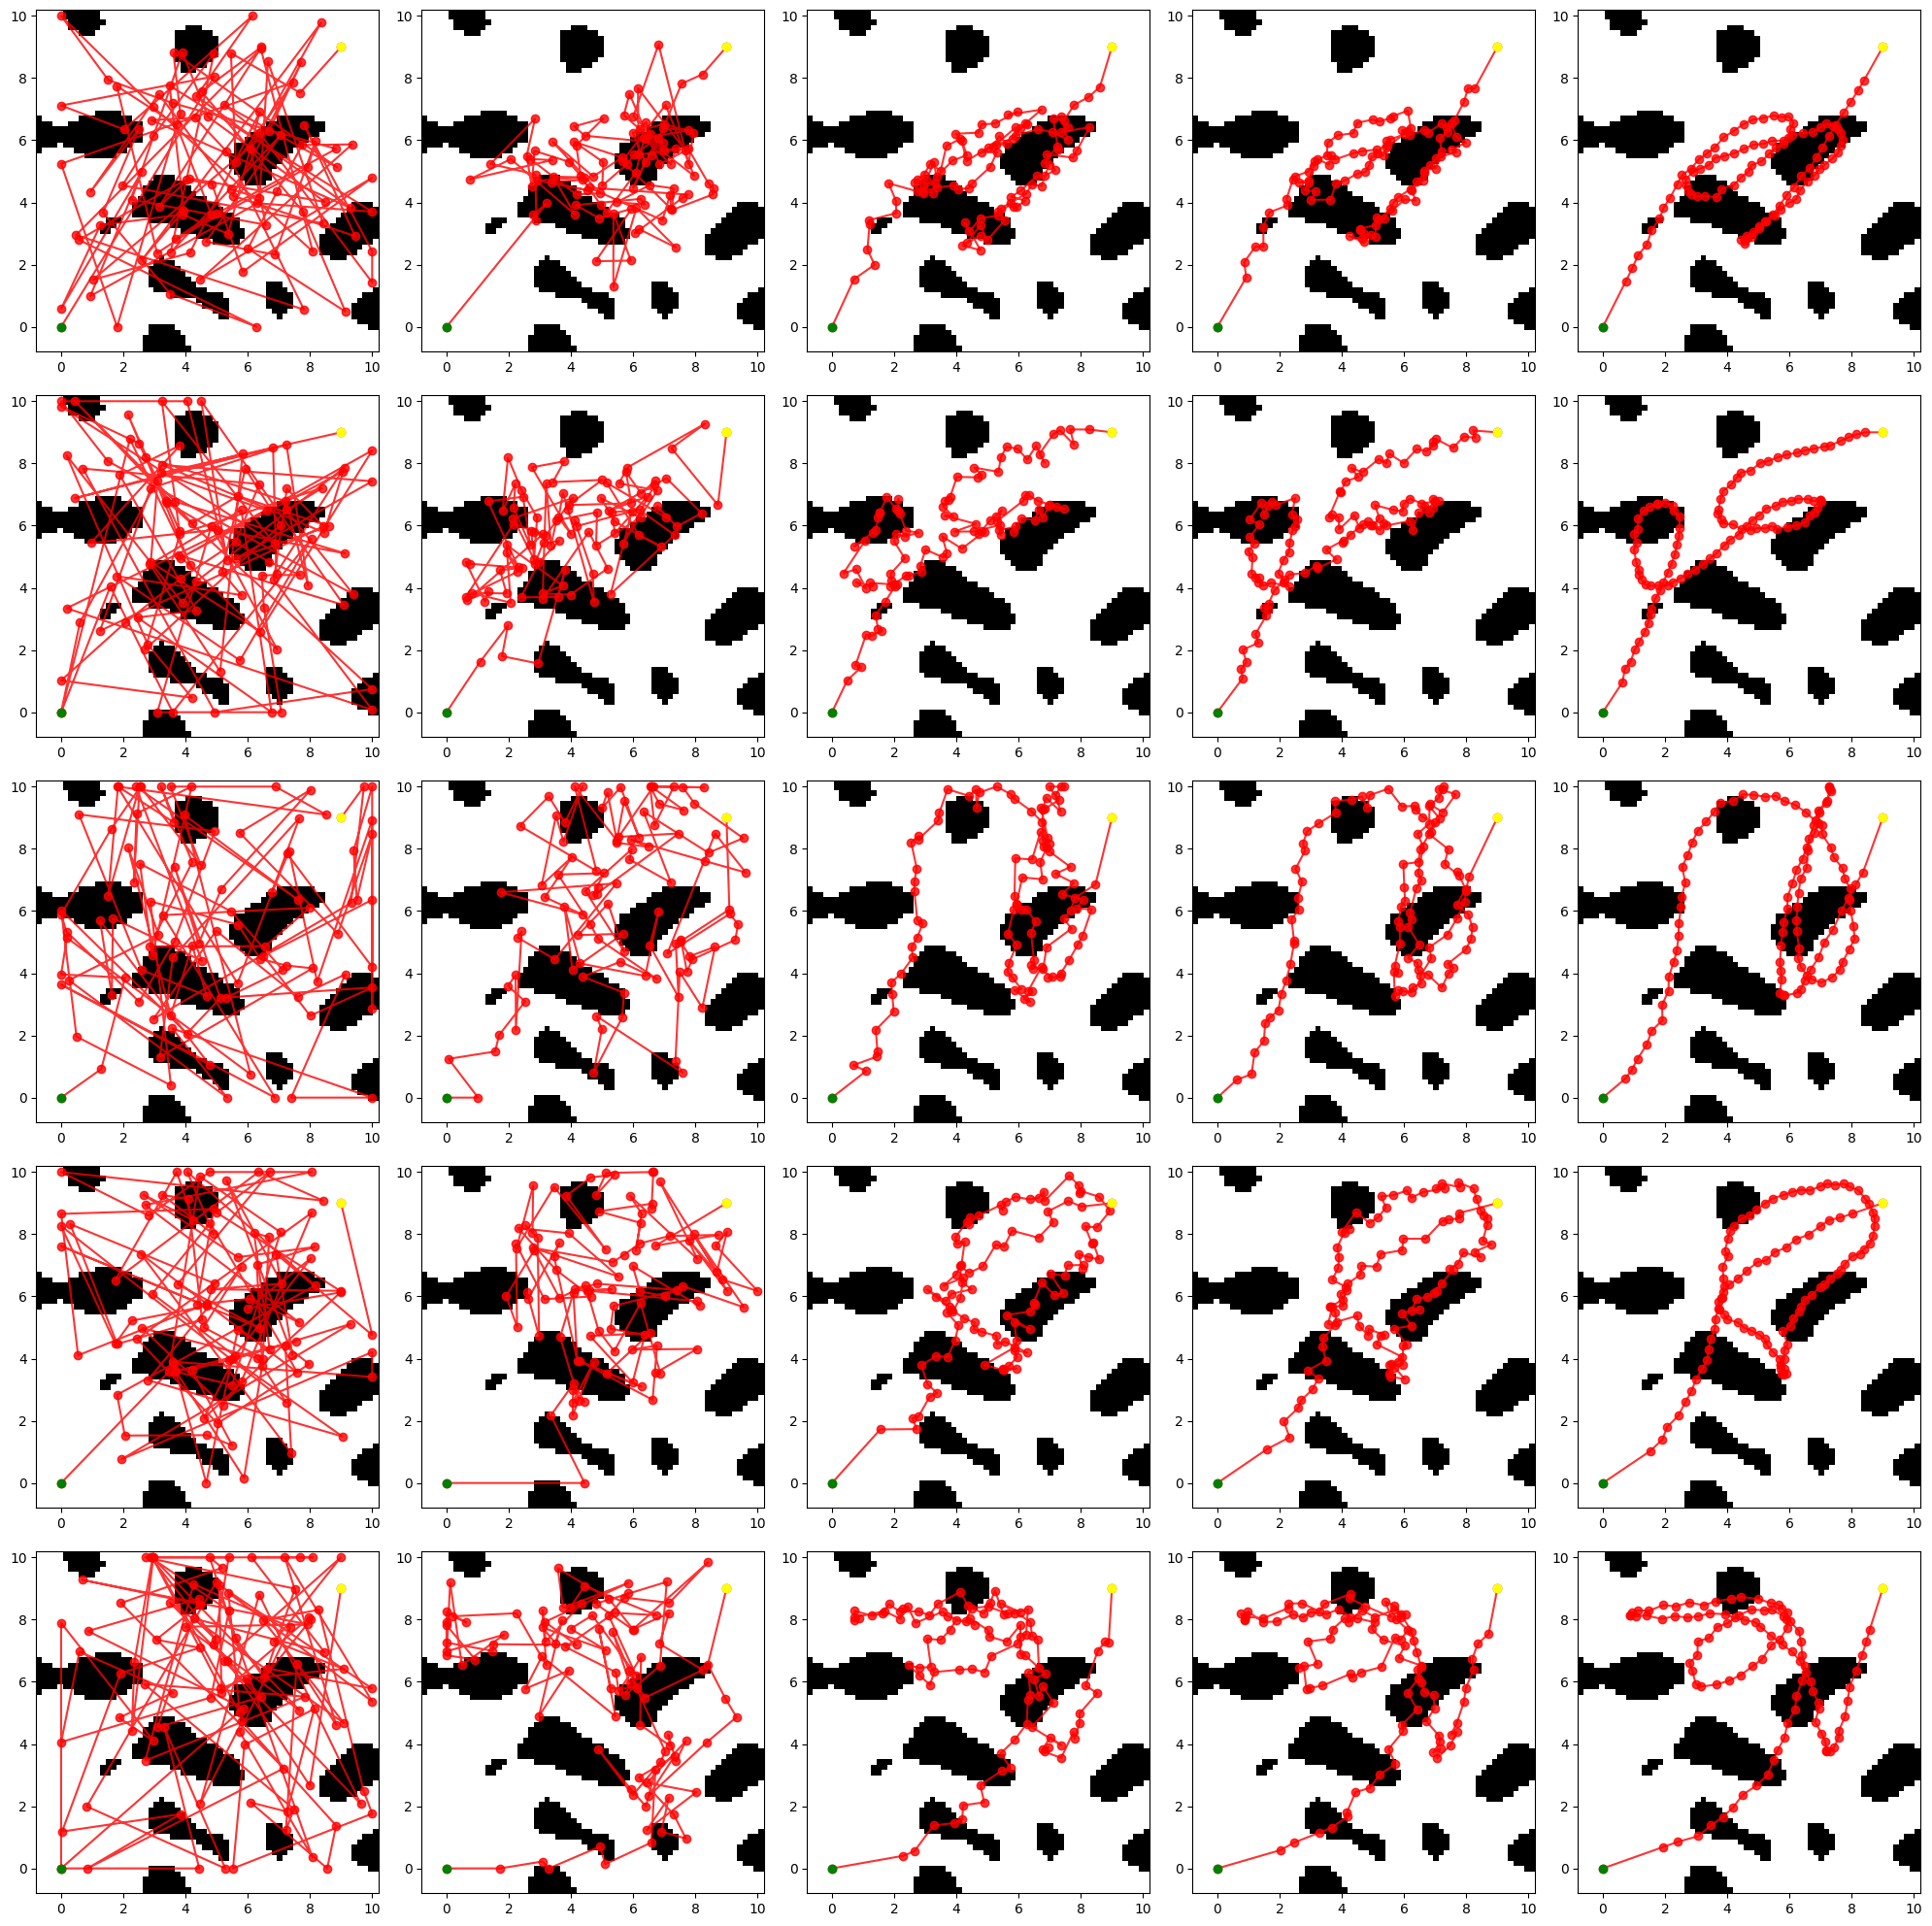

In [ ]:
plot

In [ ]:
# Get a real path from the dataset and use it's start and end point as constraints then plot both besides each other
random_indx = random.randint(0, len(dataset))
item = dataset.get_og_item(random_indx)
real_path = item['path']
starting_point = real_path[0]
end_point = real_path[-1]
world_img = item['world_img']
world_imgs = [world_img for i in range(n)]
world_distance_field_img = item['world_distance_field_img']
cond = world_distance_field_img.unsqueeze(0).repeat(n,1,1).to(device)
cond.shape , random_indx

(torch.Size([5, 64, 64]), 6064)

99it [00:02, 47.82it/s]


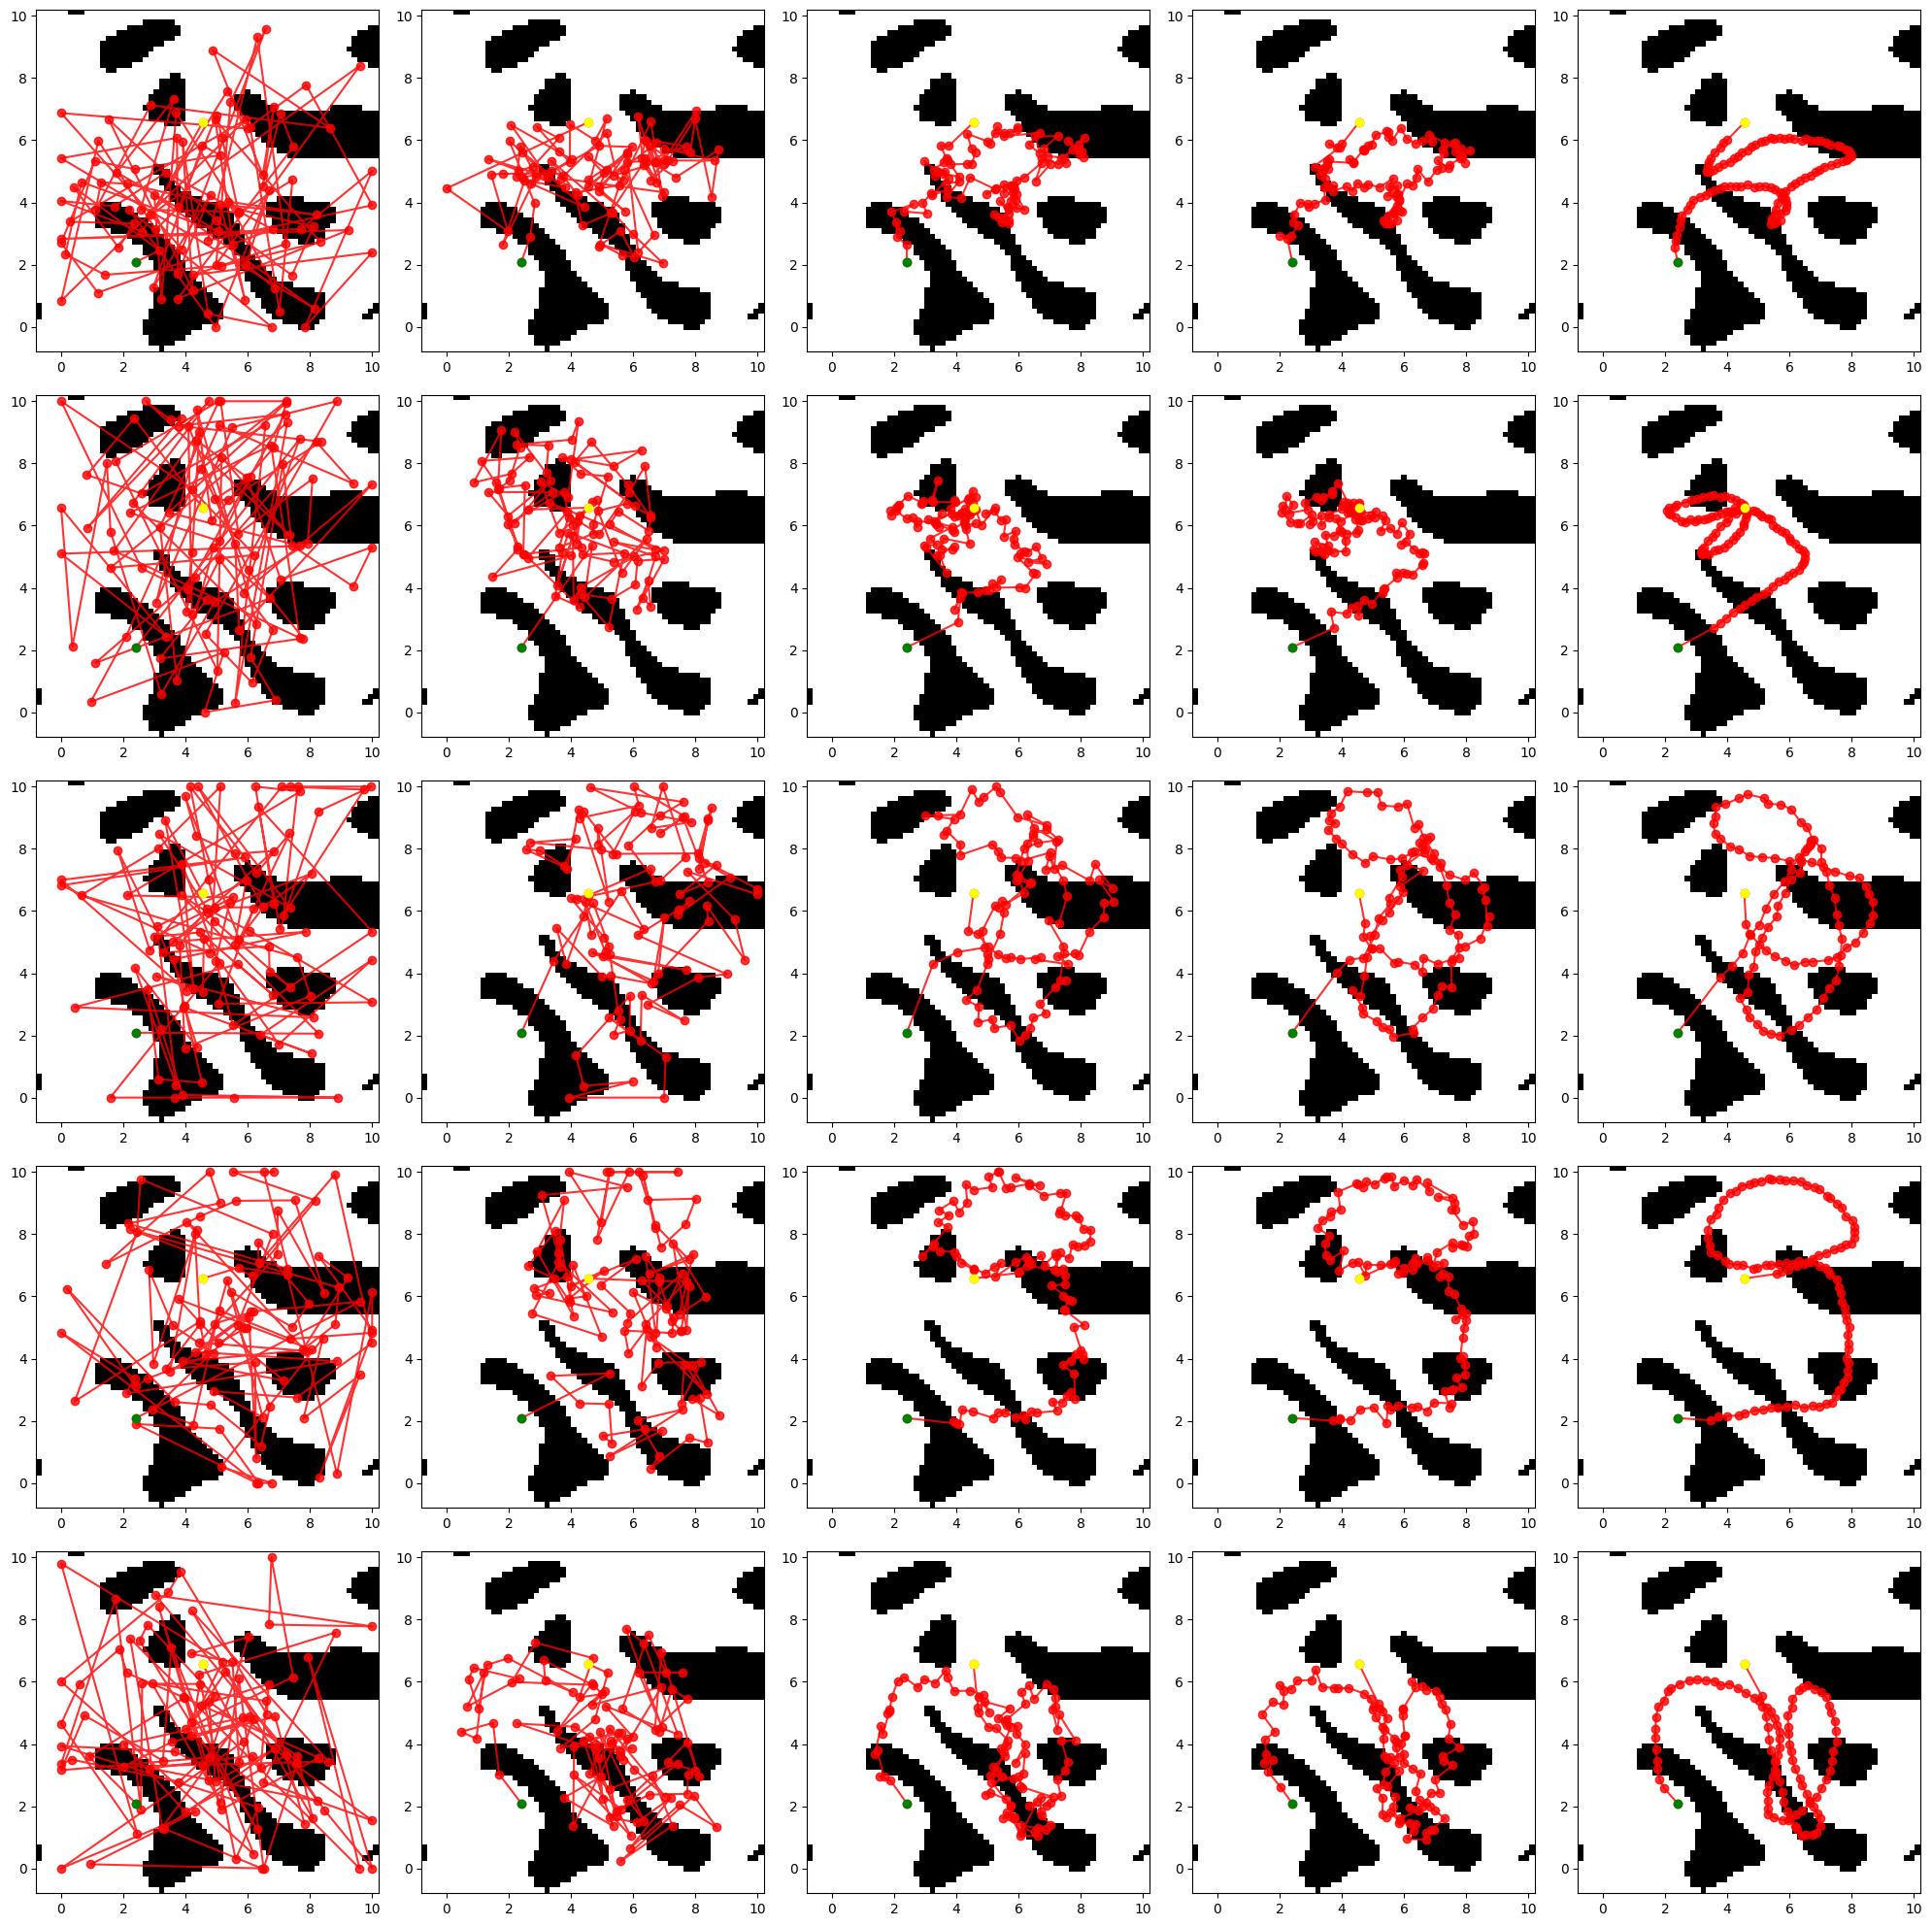

In [ ]:
constraints = {
    0: starting_point,
    99: end_point,
}
samples, intermediates = diffusion.sample_with_constraints(model, n=n, constraints=constraints,normalizer=CONFIG['normalizer'], cond=cond)
plot = plot_diffusions(intermediates, world_imgs=world_imgs, normalizer=CONFIG['normalizer'])

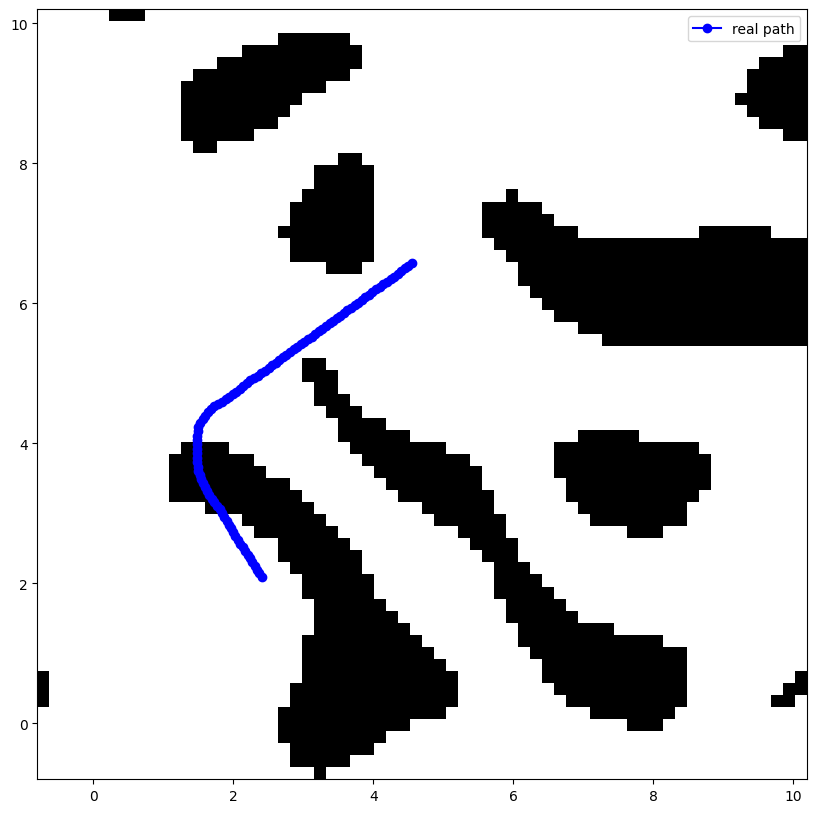

In [ ]:
# plot the real path
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
real_path = real_path.cpu().detach().numpy()
ax.plot(real_path[:, 0], real_path[:, 1], 'o-', label='real path', color='blue')
ax.imshow(world_img.T, extent=[0, 10, 0, 10], origin='lower', cmap='binary')
plt.legend()

In [ ]:
logging_manager.save_checkpoint(model, optimizer, scheduler,epoch, loss)

In [ ]:
# # Save final model
torch.save(model.state_dict(), 'model.pth')

# Sample Model

In [ ]:
# load checkpoint
model, _, _, _, _, = logging_manager.load_checkpoint(model, optimizer, scheduler, filename=r'D:\Desktop\ADLR\RobotPathData\logs\dummy-path-dataset\14h-36m-11-05-2024\model-epoch_39-loss_0.121-time_16h-48m-11-05-2024')

99it [00:01, 50.69it/s]


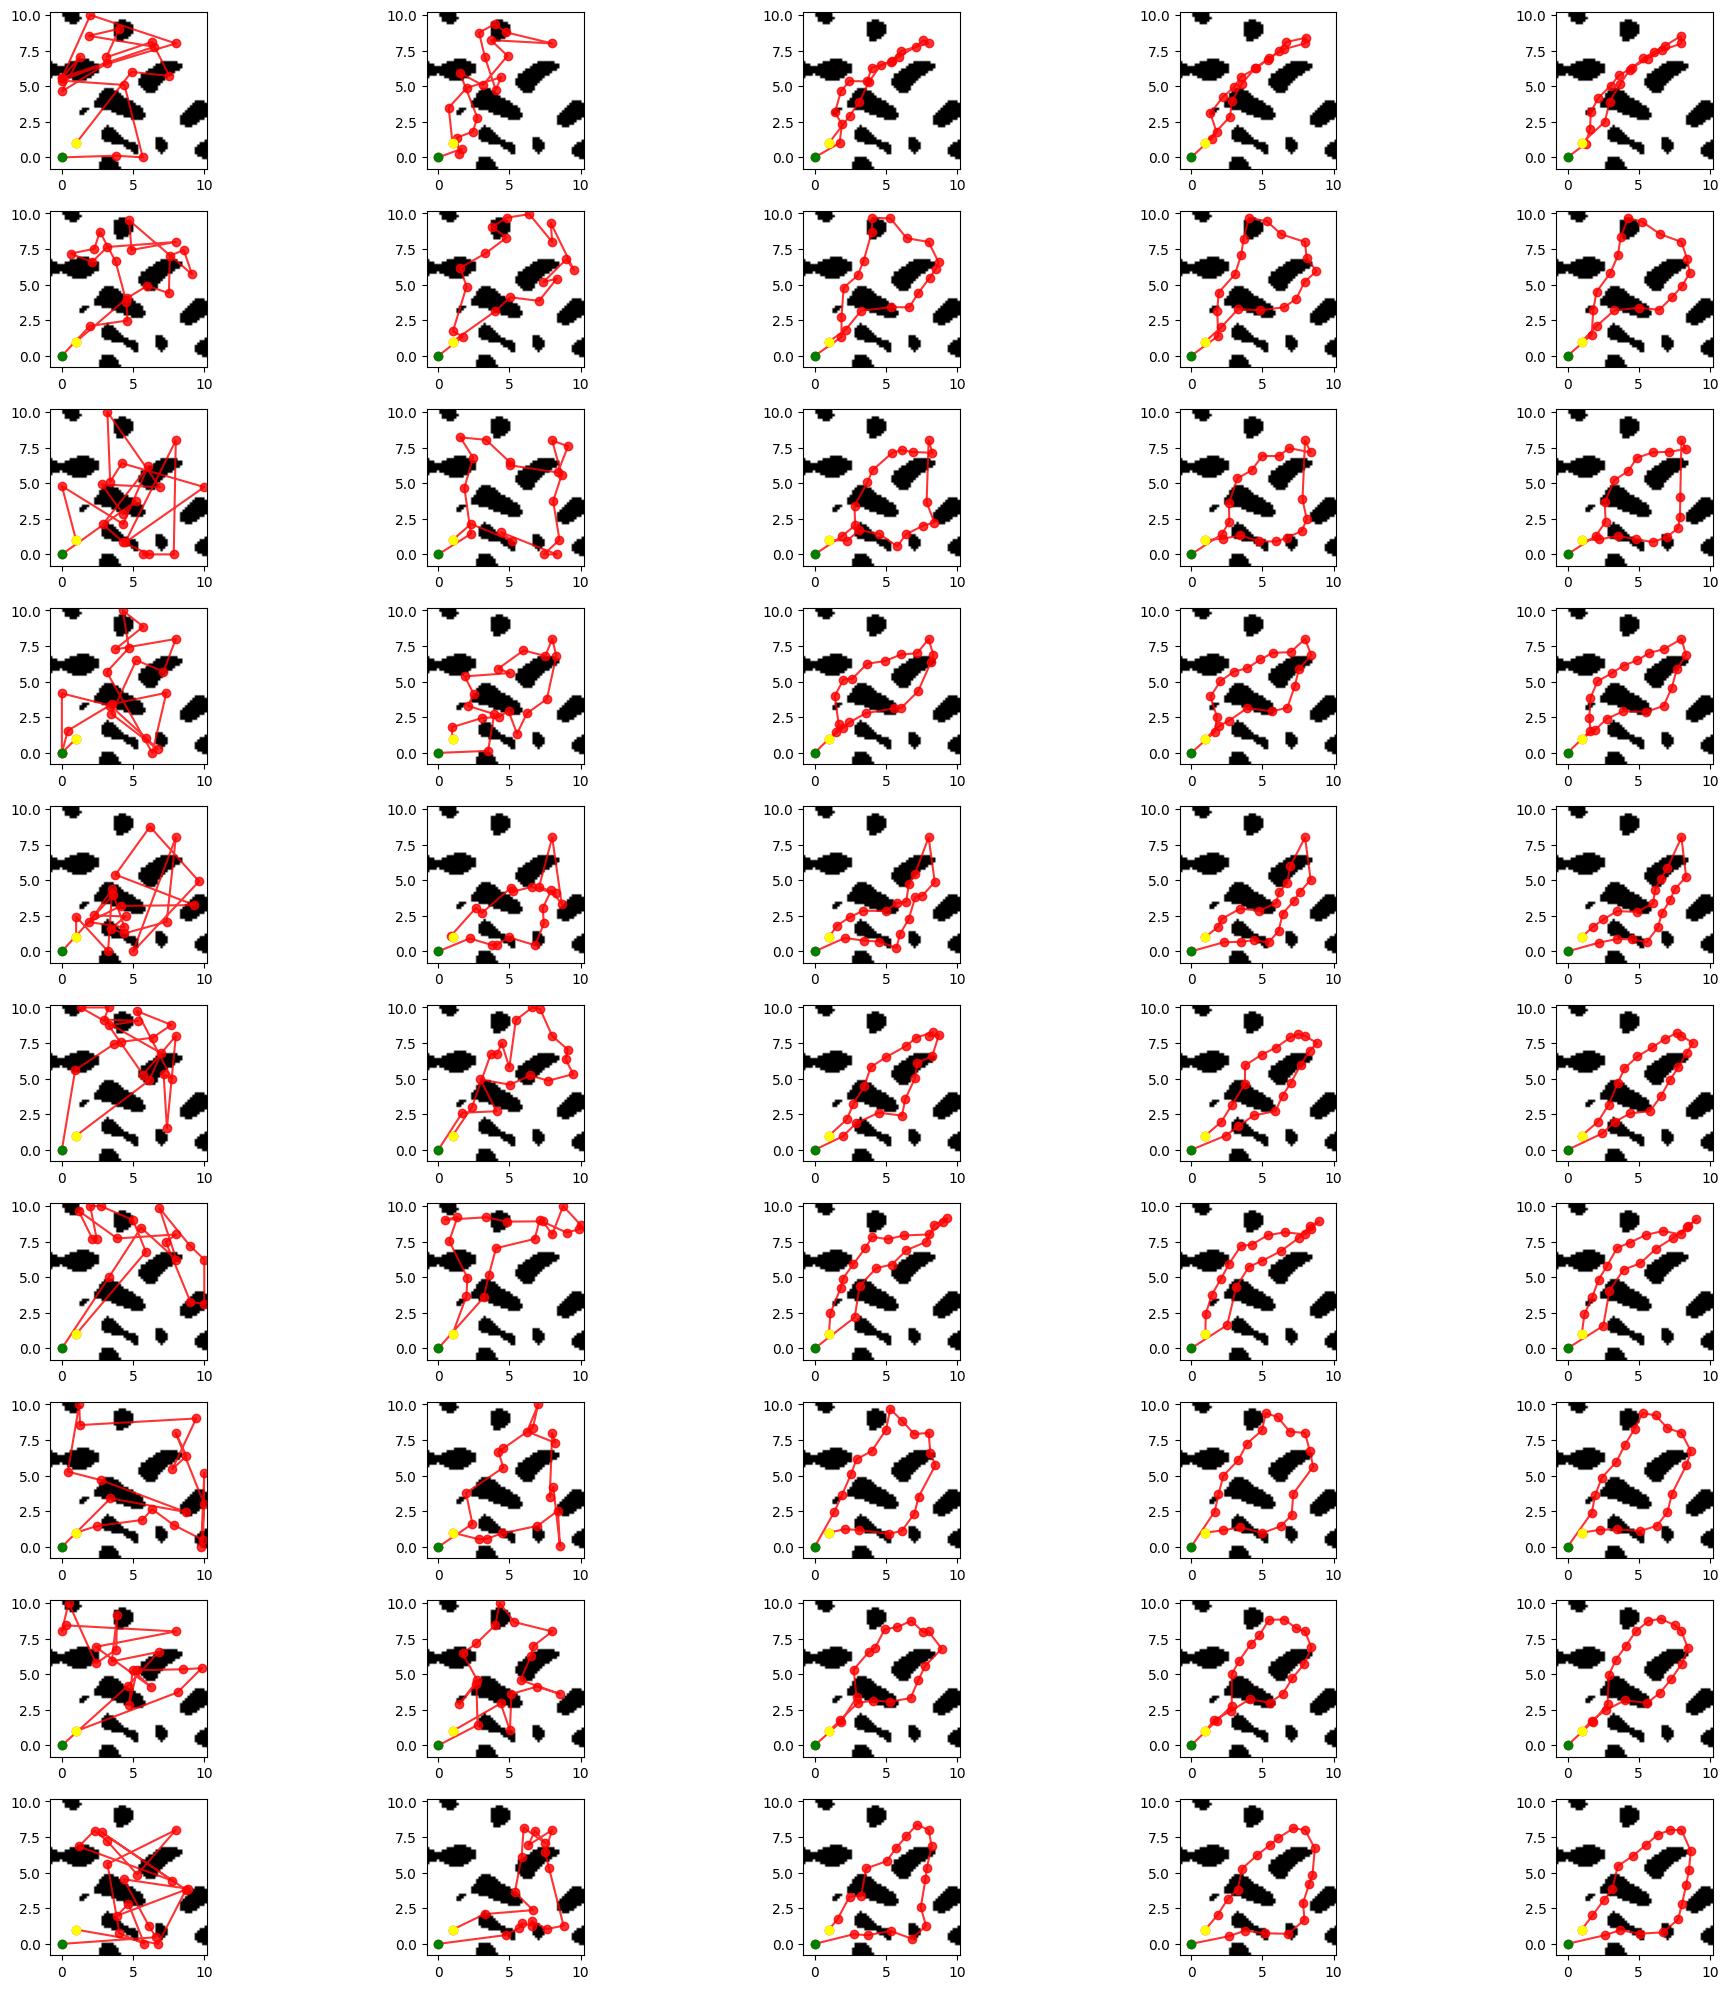

In [ ]:
# create constraints dict 
constraints = {
    0: torch.tensor([0, 0], device=device),
    10: torch.tensor([8, 8],device=device),
    19: torch.tensor([1, 1],device=device),
}
# sample from final model
samples, intermediates = diffusion.sample_with_constraints(model, 10, constraints, normalizer=CONFIG['normalizer'])
plot = plot_diffusions(intermediates, world_img=WORLD_IMG, normalizer=CONFIG['normalizer'])